# A/B-тест оплаты и сегментация клиентов

## Краткий вывод

### Полная версия с двумя понятными функциями

Основной анализ написан линейно. В конце добавлены только две функции, которые прямо требуются в задании. Все действия идут по порядку:

1. загружаем файлы;
2. добавляем новые группы;
3. проверяем данные;
4. считаем метрики;
5. проверяем статистическую значимость;
6. строим графики;
7. формулируем решение.

**Главный вывод:** новую механику пока не нужно раскатывать на всех. Значимо вырос
только `ARPPU`, а рост `ARPU` не подтверждён и конверсия не улучшилась.

## 1. Импорт библиотек

- `pandas` — таблицы и расчёты;
- `matplotlib` и `seaborn` — графики;
- `scipy` и `statsmodels` — готовые статистические тесты.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
from statsmodels.stats.proportion import (
    confint_proportions_2indep,
    proportions_ztest,
)
from statsmodels.stats.weightstats import CompareMeans, DescrStatsW

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:,.4f}".format)
sns.set_theme(style="whitegrid")

DATA_DIR = Path("../data/raw")

## 2. Загрузка четырёх файлов

Заголовки `groups_add` могут отличаться, поэтому после загрузки просто задаём
двум столбцам правильные названия по их позиции.

In [2]:
groups = pd.read_csv(DATA_DIR / "Проект_2_groups.csv", sep=";")
groups_add = pd.read_csv(DATA_DIR / "Проект_2_group_add.csv", sep=",")
active_studs = pd.read_csv(
    DATA_DIR / "Проект_2_active_studs.csv",
    sep=";",
)
checks = pd.read_csv(DATA_DIR / "Проект_2_checks.csv", sep=";")

groups.columns = ["student_id", "grp"]
groups_add.columns = ["student_id", "grp"]

print("groups:", groups.shape)
print("groups_add:", groups_add.shape)
print("active_studs:", active_studs.shape)
print("checks:", checks.shape)

groups: (74484, 2)
groups_add: (92, 2)
active_studs: (8341, 1)
checks: (541, 2)


## 3. Добавление новых пользователей

`groups_add` содержит 92 назначения, полученные позже. Добавляем их к основной
таблице через `pd.concat`.

In [3]:
all_groups = pd.concat(
    [groups, groups_add],
    ignore_index=True,
)

print("Всего назначений:", len(all_groups))
print()
print(all_groups["grp"].value_counts())

Всего назначений: 74576

grp
B    59883
A    14693
Name: count, dtype: int64


## 4. Простые проверки качества

Проверяем самое важное:

- нет ли пропусков;
- не повторяются ли пользователи;
- всем ли активным и оплатившим назначена группа;
- сколько оплативших отсутствует среди активных.

In [4]:
print("Пропуски в groups:", groups.isna().sum().sum())
print("Пропуски в groups_add:", groups_add.isna().sum().sum())
print("Пропуски в active_studs:", active_studs.isna().sum().sum())
print("Пропуски в checks:", checks.isna().sum().sum())
print()
print(
    "Дубли student_id:",
    all_groups["student_id"].duplicated().sum(),
)
print(
    "Активные без группы:",
    (~active_studs["student_id"].isin(all_groups["student_id"])).sum(),
)
print(
    "Плательщики без группы:",
    (~checks["student_id"].isin(all_groups["student_id"])).sum(),
)
print(
    "Плательщики без активности:",
    (~checks["student_id"].isin(active_studs["student_id"])).sum(),
)

Пропуски в groups: 0
Пропуски в groups_add: 0
Пропуски в active_studs: 0
Пропуски в checks: 0

Дубли student_id: 0
Активные без группы: 0
Плательщики без группы: 0
Плательщики без активности: 149


### Вывод по качеству

Дубликатов, пропусков назначения и конфликтов групп нет. Но 149 оплативших не
присутствуют в `active_studs`. Основной анализ проводим на активных: именно они
могли увидеть новую механику оплаты.

## 5. Собираем таблицу эксперимента

Берём активных пользователей, добавляем группу и оплату. Если оплаты нет,
записываем `0`. Столбец `payer` показывает, совершил ли пользователь оплату.

In [5]:
experiment = active_studs.merge(
    all_groups,
    on="student_id",
    how="left",
)

experiment = experiment.merge(
    checks,
    on="student_id",
    how="left",
)

experiment["rev"] = experiment["rev"].fillna(0)
experiment["payer"] = experiment["rev"] > 0

experiment.head()

,student_id,grp,rev,payer
0,581585,A,0.0000,False
1,5723133,A,0.0000,False
2,3276743,B,0.0000,False
3,4238589,A,0.0000,False
4,4475369,B,0.0000,False


## 6. Считаем метрики напрямую

- `CR` — доля оплативших среди активных;
- `ARPU` — выручка на одного активного;
- `ARPPU` — выручка на одного оплатившего.

In [6]:
metrics = experiment.groupby(
    "grp",
    as_index=False,
).agg(
    active_users=("student_id", "nunique"),
    payers=("payer", "sum"),
    revenue=("rev", "sum"),
)

metrics["CR"] = metrics["payers"] / metrics["active_users"]
metrics["ARPU"] = metrics["revenue"] / metrics["active_users"]
metrics["ARPPU"] = metrics["revenue"] / metrics["payers"]

metrics

,grp,active_users,payers,revenue,CR,ARPU,ARPPU
0,A,1538,78,"72,820.0000",0.0507,47.3472,933.5897
1,B,6803,314,"394,974.0035",0.0462,58.0588,"1,257.8790"


### Полученные значения

| Метрика | A | B | Изменение |
|---|---:|---:|---:|
| CR | 5.07% | 4.62% | −0.456 п.п. |
| ARPU | 47.35 | 58.06 | +10.71 |
| ARPPU | 933.59 | 1 257.88 | +324.29 |

В B выросли денежные метрики, но конверсия немного снизилась. Теперь нужно
понять, являются ли различия статистически значимыми.

## 7. Графики метрик

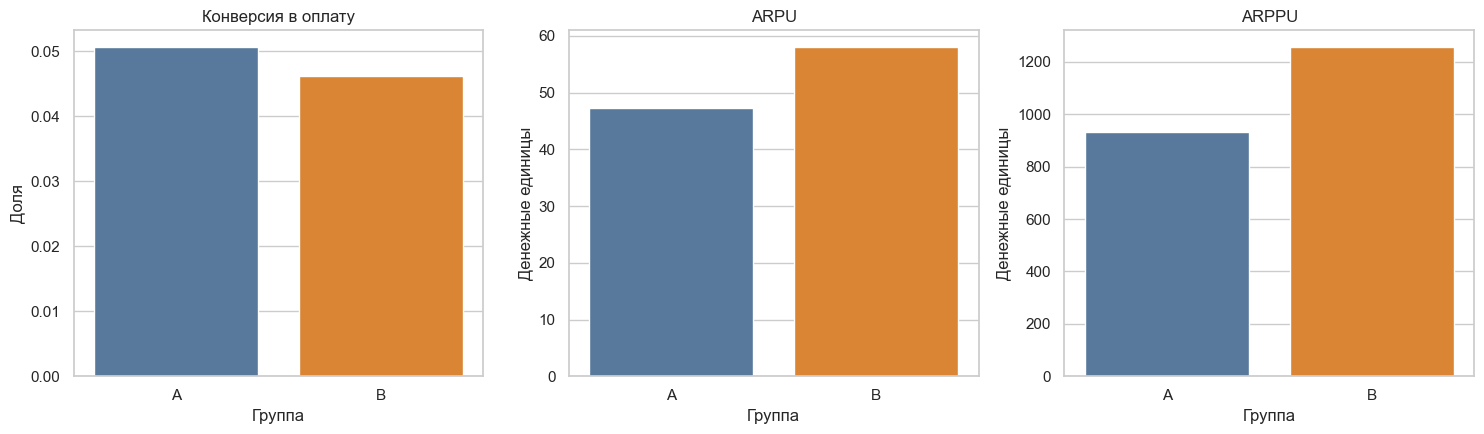

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

sns.barplot(
    data=metrics,
    x="grp",
    y="CR",
    ax=axes[0],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[0].set_title("Конверсия в оплату")
axes[0].set_xlabel("Группа")
axes[0].set_ylabel("Доля")
axes[0].set_ylim(0)

sns.barplot(
    data=metrics,
    x="grp",
    y="ARPU",
    ax=axes[1],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[1].set_title("ARPU")
axes[1].set_xlabel("Группа")
axes[1].set_ylabel("Денежные единицы")
axes[1].set_ylim(0)

sns.barplot(
    data=metrics,
    x="grp",
    y="ARPPU",
    ax=axes[2],
    hue="grp",
    palette=["#4C78A8", "#F58518"],
    legend=False,
)
axes[2].set_title("ARPPU")
axes[2].set_xlabel("Группа")
axes[2].set_ylabel("Денежные единицы")
axes[2].set_ylim(0)

plt.tight_layout()
plt.show()

## 8. Делим данные на A и B

Отдельные таблицы нужны для статистических тестов.

In [8]:
group_a = experiment[experiment["grp"] == "A"].copy()
group_b = experiment[experiment["grp"] == "B"].copy()

print("Активных A:", len(group_a))
print("Активных B:", len(group_b))
print("Плательщиков A:", group_a["payer"].sum())
print("Плательщиков B:", group_b["payer"].sum())

Активных A: 1538
Активных B: 6803
Плательщиков A: 78
Плательщиков B: 314


## 9. Проверяем предпосылки для сравнения средних

Перед выбором теста для `ARPU` и `ARPPU` проверяем:

1. форму распределений — тестом Д’Агостино и Q–Q-графиками;
2. равенство дисперсий — критерием Левена с центром по медиане.

Тест Левена выбран вместо критерия Бартлетта, потому что он устойчивее к
ненормальности и выбросам. Проверка нормальности нужна для понимания данных, но
при больших независимых выборках t-тест сравнивает средние благодаря центральной
предельной теореме: нормальным должно быть распределение среднего, а не
обязательно каждая исходная выборка.

In [9]:
payers_a = group_a[group_a["payer"]]["rev"]
payers_b = group_b[group_b["payer"]]["rev"]

arpu_normal_a = stats.normaltest(group_a["rev"])
arpu_normal_b = stats.normaltest(group_b["rev"])
arppu_normal_a = stats.normaltest(payers_a)
arppu_normal_b = stats.normaltest(payers_b)

arpu_levene = stats.levene(
    group_a["rev"],
    group_b["rev"],
    center="median",
)
arppu_levene = stats.levene(
    payers_a,
    payers_b,
    center="median",
)

assumptions = pd.DataFrame(
    {
        "metric": ["ARPU", "ARPPU"],
        "n_A": [len(group_a), len(payers_a)],
        "n_B": [len(group_b), len(payers_b)],
        "normality_p_A": [arpu_normal_a.pvalue, arppu_normal_a.pvalue],
        "normality_p_B": [arpu_normal_b.pvalue, arppu_normal_b.pvalue],
        "levene_p": [arpu_levene.pvalue, arppu_levene.pvalue],
    }
)

assumptions

,metric,n_A,n_B,normality_p_A,normality_p_B,levene_p
0,ARPU,1538,6803,0.0000,0.0000,0.2205
1,ARPPU,78,314,0.0000,0.0334,0.0803


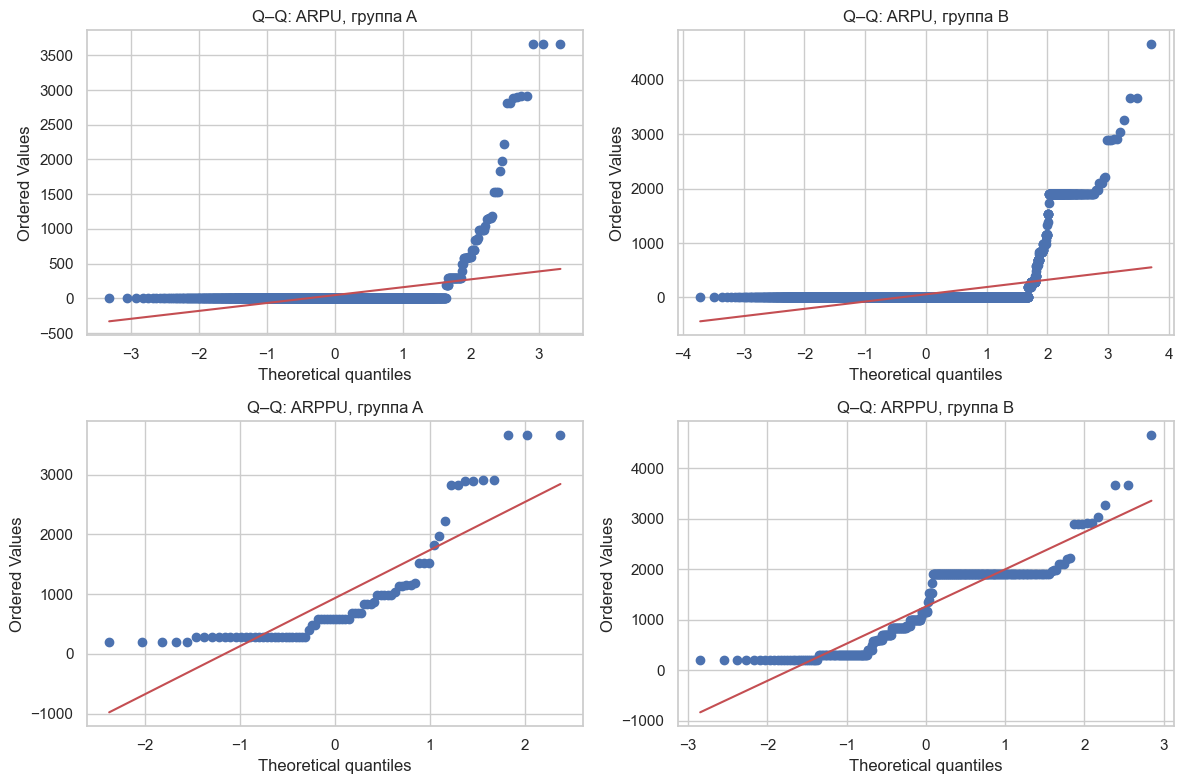

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

stats.probplot(group_a["rev"], dist="norm", plot=axes[0, 0])
axes[0, 0].set_title("Q–Q: ARPU, группа A")

stats.probplot(group_b["rev"], dist="norm", plot=axes[0, 1])
axes[0, 1].set_title("Q–Q: ARPU, группа B")

stats.probplot(payers_a, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q–Q: ARPPU, группа A")

stats.probplot(payers_b, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q–Q: ARPPU, группа B")

plt.tight_layout()
plt.show()

### Вывод по предпосылкам

- тест Д’Агостино отвергает нормальность всех четырёх распределений
  (`p < 0,05`), что согласуется с Q–Q-графиками и большим числом нулей в ARPU;
- критерий Левена не отвергает равенство дисперсий: `p = 0,2205` для ARPU и
  `p = 0,0803` для ARPPU;
- размеры групп сильно различаются: 1 538 против 6 803 активных и 78 против 314
  плательщиков.

Используем **Welch t-test**. Даже несмотря на результат Левена, он безопаснее
классического t-теста Стьюдента при несбалансированных выборках и не требует
предполагать равенство дисперсий. При таких объёмах он устойчив к ненормальности
и проверяет нужный бизнес-вопрос — равенство **средних** ARPU/ARPPU.

`Mann–Whitney` здесь не заменяет t-тест: он проверяет различие распределений и
рангов, а не непосредственно равенство средних.

## 10. Проверяем конверсию

**H0:** доля оплативших одинакова в группах A и B: $p_A = p_B$.

**H1:** доли оплативших различаются: $p_A \ne p_B$.

Используем двусторонний **z-тест двух независимых долей**, потому что результат
пользователя бинарный (`оплатил / не оплатил`), группы независимы, а количества
успехов и неуспехов в обеих группах значительно больше 5. Поэтому нормальная
аппроксимация долей применима.

In [11]:
payments = [
    group_b["payer"].sum(),
    group_a["payer"].sum(),
]

users = [
    len(group_b),
    len(group_a),
]

cr_z_stat, cr_p_value = proportions_ztest(
    payments,
    users,
)

cr_ci = confint_proportions_2indep(
    count1=int(group_b["payer"].sum()),
    nobs1=len(group_b),
    count2=int(group_a["payer"].sum()),
    nobs2=len(group_a),
    compare="diff",
    method="newcomb",
)

print("p-value CR:", round(cr_p_value, 4))
print(
    "95% CI разницы CR, п.п.:",
    round(cr_ci[0] * 100, 3),
    round(cr_ci[1] * 100, 3),
)

p-value CR: 0.4455
95% CI разницы CR, п.п.: -1.758 0.664


`p = 0,445 > 0,05`, поэтому **H0 не отвергаем**: статистически значимого
различия конверсий не обнаружено. Доверительный интервал разницы включает ноль.
Это не доказывает полного равенства групп, а означает, что имеющихся данных
недостаточно для подтверждения различия.

## 11. Проверяем ARPU

В `rev` остаются нули пользователей без оплаты. Это правильно: `ARPU` должен
учитывать всю активную аудиторию.

**H0:** средний ARPU одинаков в группах A и B: $\mu_A = \mu_B$.

**H1:** средний ARPU различается: $\mu_A \ne \mu_B$.

Используем двусторонний **Welch t-test**: наблюдения независимы, сравниваются
именно средние, выборки велики и несбалансированы. Тест не требует равенства
дисперсий и устойчив к умеренному нарушению нормальности при больших выборках.

In [12]:
arpu_test = stats.ttest_ind(
    group_b["rev"],
    group_a["rev"],
    equal_var=False,
)

arpu_ci = CompareMeans(
    DescrStatsW(group_b["rev"]),
    DescrStatsW(group_a["rev"]),
).tconfint_diff(usevar="unequal")

print("Разница ARPU:", round(group_b["rev"].mean() - group_a["rev"].mean(), 2))
print("p-value ARPU:", round(arpu_test.pvalue, 4))
print(
    "95% CI разницы ARPU:",
    round(arpu_ci[0], 2),
    round(arpu_ci[1], 2),
)

Разница ARPU: 10.71
p-value ARPU: 0.1984
95% CI разницы ARPU: -5.62 27.04


`p = 0,198 > 0,05`, поэтому **H0 не отвергаем**. Доверительный интервал
`[-5,62; 27,04]` включает ноль: статистически подтверждённого роста ARPU нет.

## 12. Проверяем ARPPU

Для `ARPPU` оставляем только оплативших пользователей.

**H0:** средний ARPPU плательщиков одинаков в группах A и B:
$\mu_A = \mu_B$.

**H1:** средний ARPPU плательщиков различается: $\mu_A \ne \mu_B$.

Используем двусторонний **Welch t-test** по той же причине: он сравнивает
средние в независимых и несбалансированных выборках и не требует равенства
дисперсий. ARPPU остаётся диагностической метрикой, поскольку условие
`пользователь заплатил` уже зависит от результата эксперимента.

In [13]:
arppu_test = stats.ttest_ind(
    payers_b,
    payers_a,
    equal_var=False,
)

arppu_ci = CompareMeans(
    DescrStatsW(payers_b),
    DescrStatsW(payers_a),
).tconfint_diff(usevar="unequal")

print("Разница ARPPU:", round(payers_b.mean() - payers_a.mean(), 2))
print("p-value ARPPU:", round(arppu_test.pvalue, 4))
print(
    "95% CI разницы ARPPU:",
    round(arppu_ci[0], 2),
    round(arppu_ci[1], 2),
)

Разница ARPPU: 324.29
p-value ARPPU: 0.0051
95% CI разницы ARPPU: 99.64 548.94


`p = 0,005 < 0,05`, поэтому **H0 отвергаем**. Доверительный интервал
`[99,64; 548,94]` не включает ноль: средний ARPPU плательщиков в B выше.
Однако это не является достаточным основанием для запуска без подтверждения
эффекта по ARPU и проверки аномального пика платежей.

## 13. Смотрим распределение платежей

График нужен, чтобы проверить, не объясняется ли среднее отдельным тарифом или
сильным пиком.

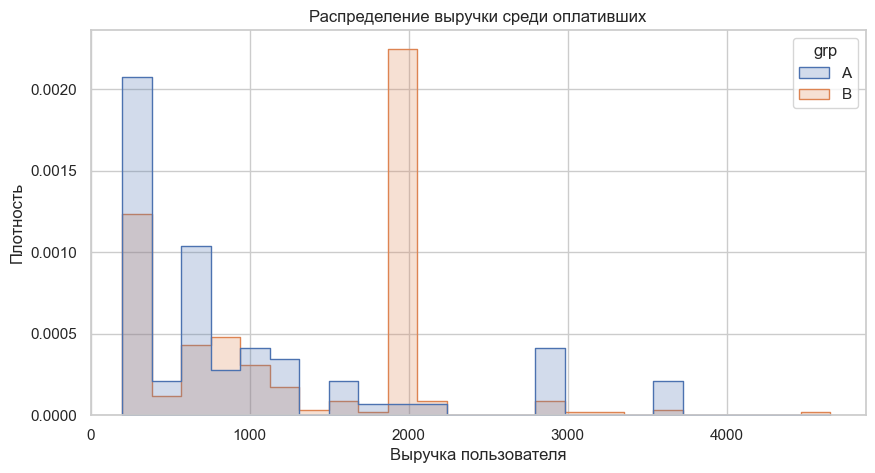

grp
B    128
dtype: int64

In [14]:
plt.figure(figsize=(10, 5))

sns.histplot(
    data=experiment[experiment["payer"]],
    x="rev",
    hue="grp",
    bins=24,
    stat="density",
    common_norm=False,
    element="step",
)

plt.title("Распределение выручки среди оплативших")
plt.xlabel("Выручка пользователя")
plt.ylabel("Плотность")
plt.xlim(left=0)
plt.show()

payments_1900 = experiment[
    experiment["payer"] & (experiment["rev"].round() == 1900)
].groupby("grp").size()

payments_1900

В B около 1900 заплатили 128 из 314 плательщиков — 40.8%. В A таких
платежей нет. Значит, рост `ARPPU` связан с изменением структуры платежей, а не
с равномерным ростом чеков у всех пользователей.

## 14. Итоговый ответ

### Факты

- `CR`: 5,07% → 4,62%; z-тест, `p = 0,445`, H0 не отвергаем;
- `ARPU`: 47,35 → 58,06; Welch t-test, `p = 0,198`, H0 не отвергаем;
- `ARPPU`: 933,59 → 1 257,88; Welch t-test, `p = 0,005`, H0 отвергаем;
- распределения ненормальны, но выборки достаточно велики для сравнения
  средних; критерий Левена не выявил значимого различия дисперсий;
- в B есть выраженный пик платежей около 1900.

### Решение

**Не раскатывать новую механику на всех пользователей прямо сейчас.**

Нужно продолжить эксперимент, проверить происхождение платежей 1900 и заранее
выбрать основную метрику. Одного значимого `ARPPU` недостаточно, потому что он
считается только среди уже оплативших, а более полная метрика `ARPU` пока не
подтвердила рост.

## 15. SQL

Для SQL-задания нужно выбрать источник **StartDA (lab)**. Готовый проверенный
запрос находится в отдельном файле `../sql/customer_segmentation.sql`.

Python здесь не нужен: запрос уже выполнен в Redash и возвращает 10 000 клиентов
с восемью требуемыми столбцами.

## 16. Функция автоматического пересчёта

По условию задания нужна функция, которая:

1. загружает основной файл групп;
2. загружает новый `groups_add`;
3. добавляет новых пользователей;
4. соединяет группы с активностью и оплатами;
5. возвращает обновлённые `CR`, `ARPU` и `ARPPU`.

В функции используются только знакомые операции: `read_csv`, `concat`, `merge`
и `groupby`. Если заголовки `groups_add` изменятся, это не сломает расчёт:
двум столбцам сразу назначаются названия `student_id` и `grp`.

In [15]:
def recalculate_metrics(data_dir, groups_add_file):
    # 1. Загружаем четыре таблицы
    groups = pd.read_csv(
        data_dir / "Проект_2_groups.csv",
        sep=";",
    )
    groups_add = pd.read_csv(
        data_dir / groups_add_file,
        sep=",",
    )
    active = pd.read_csv(
        data_dir / "Проект_2_active_studs.csv",
        sep=";",
    )
    checks = pd.read_csv(
        data_dir / "Проект_2_checks.csv",
        sep=";",
    )

    # 2. Заголовки дополнительного файла могут отличаться
    groups.columns = ["student_id", "grp"]
    groups_add.columns = ["student_id", "grp"]

    # 3. Добавляем новых пользователей
    updated_groups = pd.concat(
        [groups, groups_add],
        ignore_index=True,
    )
    updated_groups = updated_groups.drop_duplicates(
        "student_id",
        keep="last",
    )

    # 4. Собираем таблицу активных пользователей
    updated_data = active.merge(
        updated_groups,
        on="student_id",
        how="left",
    )
    updated_data = updated_data.merge(
        checks,
        on="student_id",
        how="left",
    )

    # 5. Пользователь без оплаты получает выручку 0
    updated_data["rev"] = updated_data["rev"].fillna(0)
    updated_data["payer"] = updated_data["rev"] > 0

    # 6. Считаем метрики по группам
    updated_metrics = updated_data.groupby(
        "grp",
        as_index=False,
    ).agg(
        active_users=("student_id", "nunique"),
        payers=("payer", "sum"),
        revenue=("rev", "sum"),
    )

    updated_metrics["CR"] = updated_metrics["payers"] / updated_metrics["active_users"]
    updated_metrics["ARPU"] = updated_metrics["revenue"] / updated_metrics["active_users"]
    updated_metrics["ARPPU"] = updated_metrics["revenue"] / updated_metrics["payers"]

    return updated_metrics

In [16]:
metrics_from_function = recalculate_metrics(
    data_dir=DATA_DIR,
    groups_add_file="Проект_2_group_add.csv",
)

metrics_from_function

,grp,active_users,payers,revenue,CR,ARPU,ARPPU
0,A,1538,78,"72,820.0000",0.0507,47.3472,933.5897
1,B,6803,314,"394,974.0035",0.0462,58.0588,"1,257.8790"


Получились те же значения, что и в основном анализе:

- A: `CR = 5.07%`, `ARPU = 47.35`, `ARPPU = 933.59`;
- B: `CR = 4.62%`, `ARPU = 58.06`, `ARPPU = 1 257.88`.

Значит, функция корректно добавляет `groups_add` и пересчитывает метрики.

## 17. Функция построения графиков

Вторая функция получает готовую таблицу метрик и строит три простых столбчатых
графика. Цикл не используется: каждый график записан отдельно.

In [17]:
def plot_metrics(metrics_table):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    sns.barplot(
        data=metrics_table,
        x="grp",
        y="CR",
        ax=axes[0],
        hue="grp",
        palette=["#4C78A8", "#F58518"],
        legend=False,
    )
    axes[0].set_title("Конверсия в оплату")
    axes[0].set_xlabel("Группа")
    axes[0].set_ylabel("Доля")
    axes[0].set_ylim(0)

    sns.barplot(
        data=metrics_table,
        x="grp",
        y="ARPU",
        ax=axes[1],
        hue="grp",
        palette=["#4C78A8", "#F58518"],
        legend=False,
    )
    axes[1].set_title("ARPU")
    axes[1].set_xlabel("Группа")
    axes[1].set_ylabel("Денежные единицы")
    axes[1].set_ylim(0)

    sns.barplot(
        data=metrics_table,
        x="grp",
        y="ARPPU",
        ax=axes[2],
        hue="grp",
        palette=["#4C78A8", "#F58518"],
        legend=False,
    )
    axes[2].set_title("ARPPU")
    axes[2].set_xlabel("Группа")
    axes[2].set_ylabel("Денежные единицы")
    axes[2].set_ylim(0)

    plt.tight_layout()
    plt.show()

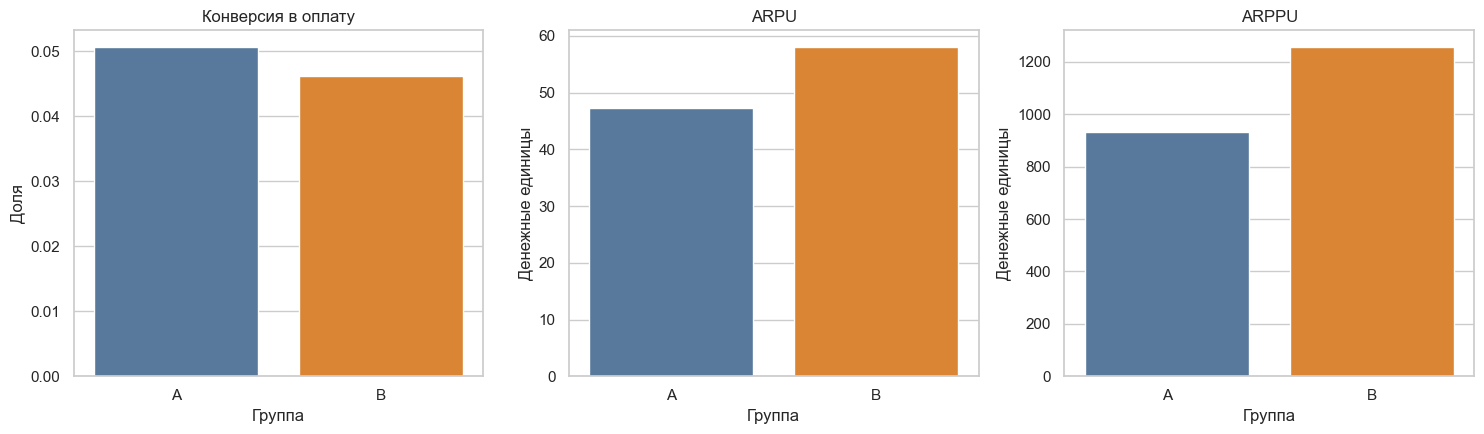

In [18]:
plot_metrics(metrics_from_function)